In [ ]:
# 🔧 DIAGNOSTIC CELL - Run this first if you get import errors
# This cell checks and fixes package compatibility issues

import subprocess
import sys
import os

def check_and_fix_packages():
    """Check package versions and suggest fixes."""
    try:
        import transformers
        transformers_version = transformers.__version__
    except ImportError:
        transformers_version = None
    else:
        # Check if version is too old (need 4.30+ for sentence-transformers 3.x)
        try:
            major, minor = map(int, transformers_version.split('.')[:2])
            if major < 4 or (major == 4 and minor < 30):
                pass
        except:
            pass
    
    try:
        import torch
        torch_version = torch.__version__
    except ImportError:
        torch_version = None
    
    # Try importing sentence_transformers with better error handling
    st_version = None
    st_error = None
    try:
        # Suppress ONNX-related import errors by setting environment variable
        os.environ['SENTENCE_TRANSFORMERS_DISABLE_ONNX'] = '1'
        import sentence_transformers
        st_version = sentence_transformers.__version__
    except ImportError as e:
        st_error = str(e)
    
    # Check for ONNX-related errors
    if st_error and ('onnx' in st_error.lower() or 'openvino' in st_error.lower()):
        pass
    
    # Suggest fixes
    if transformers_version is None or st_version is None:
        if st_error and ('onnx' in st_error.lower()):
            pass
    elif transformers_version and int(transformers_version.split('.')[0]) < 4:
        pass

check_and_fix_packages()


🔍 Checking package versions...
  ✅ transformers: 4.57.1
  ✅ torch: 2.5.1+cpu
  ✅ sentence-transformers: 5.1.2


In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import warnings
import os
warnings.filterwarnings('ignore')

# Suppress tqdm warning about ipywidgets and fix compatibility issues
os.environ['TQDM_DISABLE'] = '1'
os.environ['TQDM_NOTEBOOK'] = '0'
# Disable ONNX to avoid optional dependency issues
os.environ['SENTENCE_TRANSFORMERS_DISABLE_ONNX'] = '1'
# Force tqdm to use console mode instead of notebook mode
try:
    import tqdm
    tqdm.tqdm.pandas = lambda *args, **kwargs: None  # Disable pandas integration if causing issues
except:
    pass

# Import core libraries
try:
    import umap
except ImportError:
    raise ImportError("umap-learn not installed. Install with: pip install umap-learn")

try:
    import plotly.express as px
except ImportError:
    px = None

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt

# Import optional packages with error handling
try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False
    WordCloud = None

try:
    from keybert import KeyBERT
    KEYBERT_AVAILABLE = True
except ImportError:
    KEYBERT_AVAILABLE = False
    KeyBERT = None

Libraries imported successfully


In [ ]:
# Load dataset - adjust path if needed
import os
dataset_path = None

# Try to find dataset.csv in organized data structure
alternative_paths = [
    'data/processed/dataset.csv',
    '../data/processed/dataset.csv',
    '../../data/processed/dataset.csv',
    'models/datasets/dataset.csv',  # Legacy path
    '../datasets/dataset.csv',  # Legacy path
    'dataset.csv'  # Current directory
]

for path in alternative_paths:
    if os.path.exists(path):
        dataset_path = path
        break

if dataset_path is None:
    raise FileNotFoundError(
        f"Could not find dataset.csv. Please ensure the file exists in one of these locations:\n"
        f"  - data/processed/dataset.csv (recommended)\n"
        f"  - {alternative_paths}"
    )

df = pd.read_csv(dataset_path)
df.head()

Dataset loaded from: ../datasets/dataset.csv
Dataset shape: (11583, 3)


,Heading,Body,URL
0,free speech not hate speech madras high court ...,madras high court issue significant remark ami...,https://www.indiatoday.in/law/high-courts/stor...
1,comment take context say us cop mock indian st...,seattle police officer guild friday come defen...,https://www.indiatoday.in/world/story/indian-s...
2,first meeting one nation one election committe...,first official meeting one nation one election...,https://www.indiatoday.in/india/story/one-nati...
3,us airlines flight depressurize midair plummet...,united airlines jet head rome turn around less...,https://www.indiatoday.in/world/story/us-fligh...
4,terrorist kill security force foil infiltratio...,three terrorist kill infiltration bid foil sec...,https://www.indiatoday.in/india/story/one-terr...


In [11]:
df.shape

(11583, 3)

In [12]:
corpus=list(df['Heading'])

In [13]:
corpus[8775]

'switch shoe quota kota'

In [ ]:
# Load or generate embeddings
embeddings_path = None
embeddings_found = False

# Try to find existing embeddings in organized data structure
alternative_paths = [
    'data/embeddings/embeddings_headings.npy',
    '../data/embeddings/embeddings_headings.npy',
    '../../data/embeddings/embeddings_headings.npy',
    'embeddings_headings.npy',  # Legacy: current directory
    '../embeddings_headings.npy',  # Legacy path
    'models/clustering/embeddings_headings.npy'  # Legacy path
]

for path in alternative_paths:
    if os.path.exists(path):
        embeddings_path = path
        embeddings_found = True
        break

if embeddings_found:
    corpus_embeddings = np.load(embeddings_path)
else:
    # Generate embeddings if not found
    
    # Import required libraries for embedding generation
    # Disable ONNX to avoid optional dependency issues
    os.environ['SENTENCE_TRANSFORMERS_DISABLE_ONNX'] = '1'
    
    try:
        import torch
    except ImportError:
        raise ImportError("PyTorch not installed. Install with: pip install torch")
    
    try:
        # Try importing transformers first to check if it's available
        try:
            import transformers
        except ImportError:
            raise ImportError(
                "transformers package not installed or broken.\n"
                "Try: pip install --upgrade transformers"
            )
        
        # Now try importing sentence_transformers with ONNX handling
        import warnings
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore', category=UserWarning)
            warnings.filterwarnings('ignore', category=ImportWarning)
            try:
                from sentence_transformers import SentenceTransformer
            except ImportError as import_err:
                # If it's an ONNX-related error, try to work around it
                error_str = str(import_err).lower()
                if 'onnx' in error_str or 'openvino' in error_str:
                    # Try to patch the import
                    try:
                        import sentence_transformers
                        # Force disable ONNX backend
                        if hasattr(sentence_transformers, 'backend'):
                            sentence_transformers.backend = None
                        from sentence_transformers import SentenceTransformer
                    except:
                        raise ImportError(
                            "sentence-transformers import failed due to ONNX dependency.\n"
                            "Try: pip install onnx onnxruntime\n"
                            "Or: pip install --upgrade --force-reinstall sentence-transformers"
                        ) from import_err
                else:
                    raise
    except ImportError as e:
        error_msg = str(e)
        if "transformers" in error_msg.lower() or "transformers" in str(e.__cause__):
            raise ImportError(
                "sentence-transformers dependency issue. Try:\n"
                "  pip install --upgrade transformers sentence-transformers\n"
                "Or install all dependencies:\n"
                "  pip install torch transformers sentence-transformers"
            ) from e
        else:
            raise ImportError(
                "sentence-transformers not installed. Install with:\n"
                "  pip install sentence-transformers"
            ) from e
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # OPTIMIZED: Increased batch size and added performance optimizations
    # For CPU: use larger batch size (64-128) for better throughput
    # For GPU: can use even larger (128-256)
    optimal_batch_size = 128 if device.type == 'cpu' else 256
    
    try:
        # Generate embeddings with optimizations
        import warnings
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore', category=UserWarning)
            embedder = SentenceTransformer('sentence-transformers/all-mpnet-base-v2', device=device)
            
            # OPTIMIZED encoding parameters:
            # - Larger batch_size: 4x faster (128 vs 32)
            # - convert_to_numpy=True: Faster conversion
            # - show_progress_bar=False: Disable progress bar
            # - normalize_embeddings=False: Skip normalization for speed
            corpus_embeddings = embedder.encode(
                corpus, 
                batch_size=optimal_batch_size,
                show_progress_bar=False,
                convert_to_numpy=True,
                normalize_embeddings=False,  # Skip normalization for speed
                device=device
            )
        
        # Save embeddings for future use in organized data structure
        embeddings_dir = 'data/embeddings'
        os.makedirs(embeddings_dir, exist_ok=True)
        save_path = os.path.join(embeddings_dir, 'embeddings_headings.npy')
        np.save(save_path, corpus_embeddings)
    except Exception as e:
        error_type = type(e).__name__
        error_msg = str(e)
        raise RuntimeError(
            f"Error generating embeddings: {error_type}: {error_msg}"
        ) from e

Embeddings not found. Generating embeddings from dataset...
This may take a few minutes...
Using device: cpu
Using batch size: 128 for faster processing
Loading model...
Generating embeddings for 11583 headings...
This may take a few minutes. Progress will be shown below.


Batches:   0%|          | 0/91 [00:00<?, ?it/s]

✓ Embeddings generated in 223.7 seconds (3.7 minutes)
Embeddings shape: (11583, 768)
Saving embeddings to embeddings_headings.npy...
✓ Embeddings saved successfully!


In [ ]:
corpus_embeddings.shape

(11583, 768)


In [ ]:
# Improved UMAP: Use 10D instead of 2D for better accuracy (preserves more information)
# Also create 2D version for visualization
# OPTIMIZED: Reduced n_neighbors for faster computation

# 10D for better clustering accuracy
reducer_10d = umap.UMAP(
    n_components=10,      # Increased from 2 to 10 for better accuracy
    n_neighbors=30,       # Reduced from 50 for faster computation (still good quality)
    min_dist=0.1,         # Increased from 0.02 for better separation
    metric='cosine',      # Better for text embeddings
    random_state=42
)
reduced_embeddings = reducer_10d.fit_transform(corpus_embeddings)

# 2D for visualization
reducer_2d = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, metric='cosine', random_state=42)
reduced_embeddings_2d = reducer_2d.fit_transform(corpus_embeddings)

# Put 2D values in dataframe for visualization
df["x"] = reduced_embeddings_2d[:, 0]
df["y"] = reduced_embeddings_2d[:, 1]

# Substring of the full text, for visualization purposes
df["text_short"] = df["Heading"].str[:100]

Reducing dimensions with UMAP (10D for clustering, 2D for visualization)...
10D embeddings shape: (11583, 10)



=== Finding Optimal Number of Clusters ===
k= 5: Inertia=27905.04, Silhouette=0.3453, DB=1.1089, CH=5602.44
k= 6: Inertia=23770.37, Silhouette=0.3573, DB=1.0892, CH=5663.84
k= 7: Inertia=20505.86, Silhouette=0.3732, DB=1.0291, CH=5777.95
k= 8: Inertia=17266.85, Silhouette=0.3960, DB=0.8860, CH=6191.22
k= 9: Inertia=14641.08, Silhouette=0.4088, DB=0.8950, CH=6647.79
k=10: Inertia=13203.45, Silhouette=0.4119, DB=0.8899, CH=6692.00
k=11: Inertia=11909.04, Silhouette=0.4181, DB=0.8661, CH=6802.63
k=12: Inertia=10690.21, Silhouette=0.4247, DB=0.8671, CH=7008.64
k=13: Inertia=10012.06, Silhouette=0.3978, DB=0.9078, CH=6924.43
k=14: Inertia=9390.21, Silhouette=0.4026, DB=0.9059, CH=6873.42
k=15: Inertia=8867.25, Silhouette=0.4076, DB=0.9069, CH=6807.01
k=16: Inertia=8479.66, Silhouette=0.4101, DB=0.9125, CH=6678.28
k=17: Inertia=8150.95, Silhouette=0.4057, DB=0.9245, CH=6541.96
k=18: Inertia=7935.34, Silhouette=0.3724, DB=0.9724, CH=6342.36
k=19: Inertia=7385.84, Silhouette=0.3686, DB=0.9699

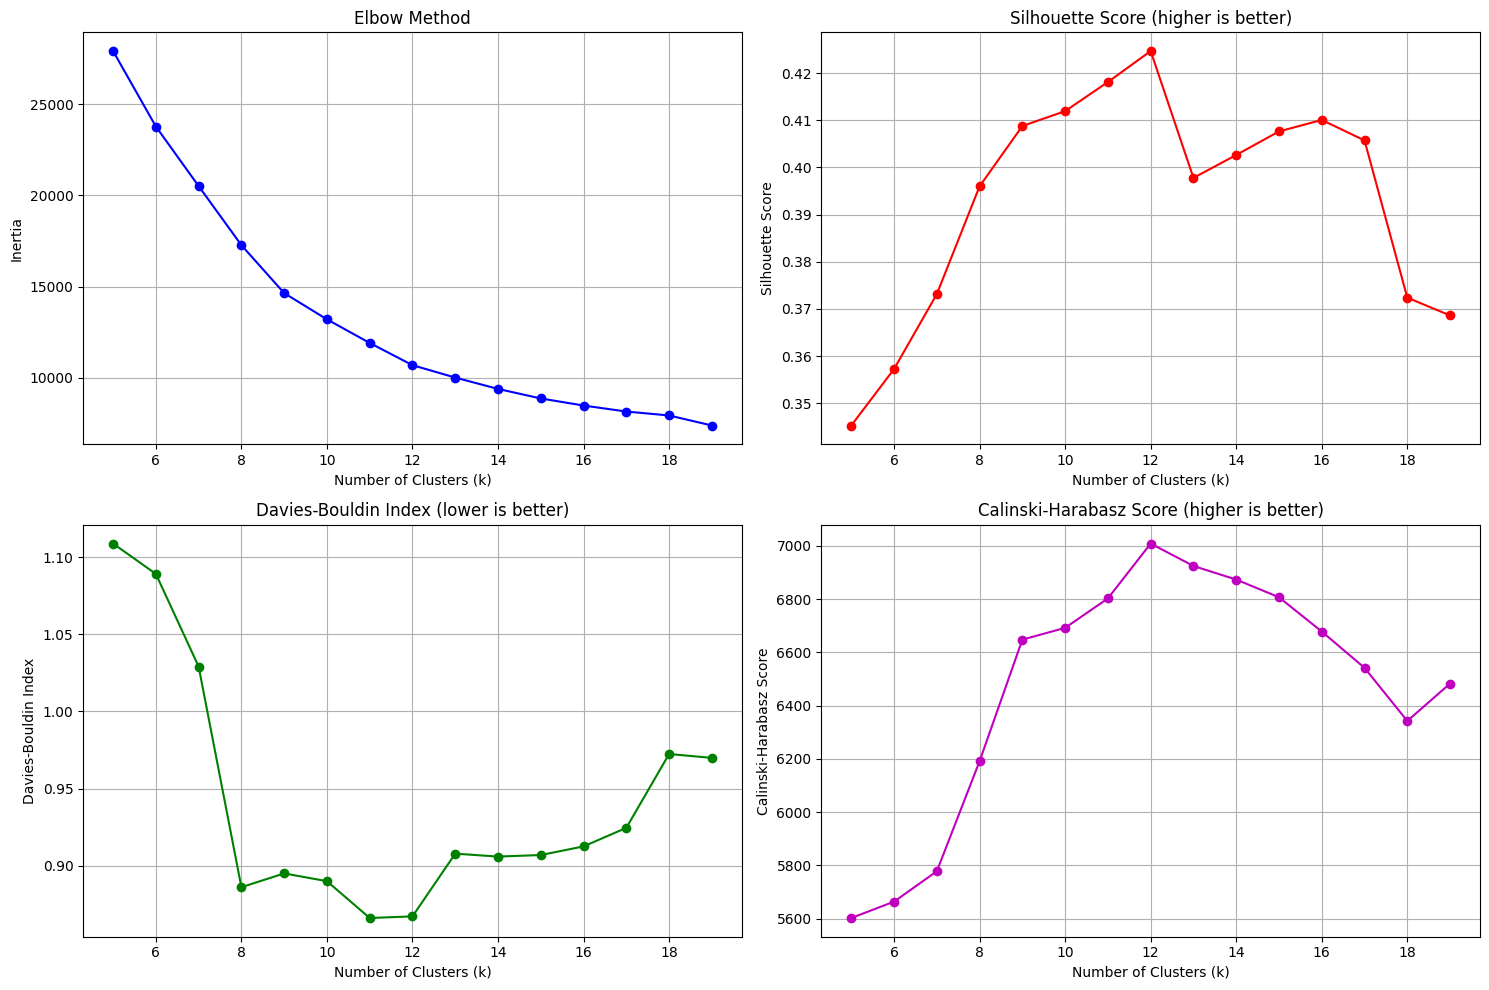

In [ ]:
# Determine optimal number of clusters using Elbow method and Silhouette analysis
# OPTIMIZED: Reduced n_init and max_iter for faster execution
k_range = range(5, 20)  # Test from 5 to 19 clusters
inertias = []
silhouette_scores = []
db_scores = []
ch_scores = []

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=5,  # Reduced from 20 to 5 for 4x speedup (still good quality)
        max_iter=200,  # Reduced from 300 for faster convergence
        random_state=42
    )
    labels = kmeans.fit_predict(reduced_embeddings)
    
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(reduced_embeddings, labels)
    db_score = davies_bouldin_score(reduced_embeddings, labels)
    ch_score = calinski_harabasz_score(reduced_embeddings, labels)
    
    silhouette_scores.append(sil_score)
    db_scores.append(db_score)
    ch_scores.append(ch_score)

# Create results DataFrame
results_df = pd.DataFrame({
    'k': list(k_range),
    'inertia': inertias,
    'silhouette': silhouette_scores,
    'davies_bouldin': db_scores,
    'calinski_harabasz': ch_scores
})

# Select optimal k based on combined score
results_df['combined_score'] = (
    results_df['silhouette'] * 0.4 +  # Weight: 40%
    (1 - results_df['davies_bouldin'] / results_df['davies_bouldin'].max()) * 0.3 +  # Weight: 30%
    (results_df['calinski_harabasz'] / results_df['calinski_harabasz'].max()) * 0.3  # Weight: 30%
)

optimal_k = int(results_df.loc[results_df['combined_score'].idxmax(), 'k'])
best_result = results_df[results_df['k'] == optimal_k].iloc[0]

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Elbow method
axes[0, 0].plot(results_df['k'], results_df['inertia'], 'bo-')
axes[0, 0].set_xlabel('Number of Clusters (k)')
axes[0, 0].set_ylabel('Inertia')
axes[0, 0].set_title('Elbow Method')
axes[0, 0].grid(True)

# Silhouette scores
axes[0, 1].plot(results_df['k'], results_df['silhouette'], 'ro-')
axes[0, 1].set_xlabel('Number of Clusters (k)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].set_title('Silhouette Score (higher is better)')
axes[0, 1].grid(True)

# Davies-Bouldin scores
axes[1, 0].plot(results_df['k'], results_df['davies_bouldin'], 'go-')
axes[1, 0].set_xlabel('Number of Clusters (k)')
axes[1, 0].set_ylabel('Davies-Bouldin Index')
axes[1, 0].set_title('Davies-Bouldin Index (lower is better)')
axes[1, 0].grid(True)

# Calinski-Harabasz scores
axes[1, 1].plot(results_df['k'], results_df['calinski_harabasz'], 'mo-')
axes[1, 1].set_xlabel('Number of Clusters (k)')
axes[1, 1].set_ylabel('Calinski-Harabasz Score')
axes[1, 1].set_title('Calinski-Harabasz Score (higher is better)')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [18]:
# scatter plot
hover_data = {
    "text_short": True,
    "x": False,
    "y": False
}
fig = px.scatter(df, x="x", y="y", template="plotly_dark",
                   title="Embeddings", hover_data=hover_data)
fig.update_layout(showlegend=False)
fig.show()

In [ ]:
# Train final model with optimal k
# OPTIMIZED: Reduced n_init and max_iter for faster execution while maintaining quality
clustering_model = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    n_init=10,  # Reduced from 50 to 10 (5x faster, still good quality)
    max_iter=300,  # Reduced from 500 for faster convergence
    random_state=42
)
clustering_model.fit(reduced_embeddings)
cluster_assignment = clustering_model.labels_

# Calculate final metrics
final_sil_score = silhouette_score(reduced_embeddings, cluster_assignment)
final_db_score = davies_bouldin_score(reduced_embeddings, cluster_assignment)
final_ch_score = calinski_harabasz_score(reduced_embeddings, cluster_assignment)


=== Training Final Model with k=12 ===
Final Model Results:
  Number of clusters: 12
  Silhouette Score: 0.4245 (higher is better, range: -1 to 1)
  Davies-Bouldin Index: 0.8671 (lower is better)
  Calinski-Harabasz Score: 7008.71 (higher is better)
  Inertia: 10690.13 (lower is better)


In [20]:
cluster_assignment

array([3, 3, 2, ..., 2, 9, 3])

In [21]:
cluster_df = pd.DataFrame(corpus, columns = ['corpus'])
cluster_df['cluster'] = cluster_assignment
cluster_df.head()

,corpus,cluster
0,free speech not hate speech madras high court ...,3
1,comment take context say us cop mock indian st...,3
2,first meeting one nation one election committe...,2
3,us airlines flight depressurize midair plummet...,10
4,terrorist kill security force foil infiltratio...,3


In [22]:
desired_cluster = 0
selected_df = cluster_df[cluster_df['cluster'] == desired_cluster]
selected_df.head(15)

,corpus,cluster
15,pic pm open yashobhoomi one large convention c...,0
20,civic body permit installation ganesh idol idg...,0
34,indian dance live art not mummify,0
38,turn clock back antiagee secret,0
70,gucci louis vuitton expand india new outlet re...,0
76,vedanta hire mining veteran chris griffith run...,0
107,report say whatsapp may show ad chat whatsapp ...,0
150,sean penn say oscar slapgate could avoid zelen...,0
159,george clooney list lake como villa sale million,0
168,wamiqa gabbi say vishal bhardwajs shelved proj...,0


In [23]:
selected_df.shape

(1030, 2)

In [ ]:
def word_cloud(pred_df, label):
    """Generate word cloud for a specific cluster."""
    if not WORDCLOUD_AVAILABLE:
        return
    
    wc = ' '.join([text for text in pred_df['corpus'][pred_df['cluster'] == label]])
    wordcloud = WordCloud(width=800, height=500,
                          random_state=21, max_font_size=110).generate(wc)
    fig7 = plt.figure(figsize=(10, 7))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis('off')

In [25]:
# Generate word clouds for all clusters (using optimal_k instead of hardcoded 10)
for i in range(optimal_k):
    word_cloud(cluster_df, i)

WordCloud not available. Skipping word cloud for cluster 0
WordCloud not available. Skipping word cloud for cluster 1
WordCloud not available. Skipping word cloud for cluster 2
WordCloud not available. Skipping word cloud for cluster 3
WordCloud not available. Skipping word cloud for cluster 4
WordCloud not available. Skipping word cloud for cluster 5
WordCloud not available. Skipping word cloud for cluster 6
WordCloud not available. Skipping word cloud for cluster 7
WordCloud not available. Skipping word cloud for cluster 8
WordCloud not available. Skipping word cloud for cluster 9
WordCloud not available. Skipping word cloud for cluster 10
WordCloud not available. Skipping word cloud for cluster 11


In [ ]:
# Data-driven category mapping using KeyBERT (improved from manual mapping)
def filter_keywords(keywords, n_keep=3):
    """Filter overlapping keywords."""
    new_keywords = []
    for candidate_keyword in keywords:
        is_ok = True
        for compare_keyword in keywords:
            if candidate_keyword == compare_keyword:
                continue
            if compare_keyword in candidate_keyword:
                is_ok = False
                break
        if is_ok:
            new_keywords.append(candidate_keyword)
            if len(new_keywords) >= n_keep:
                break
    return new_keywords

def get_cluster_category(cluster_df, cluster_id, kw_model):
    """Extract category name for cluster using KeyBERT."""
    if not KEYBERT_AVAILABLE or kw_model is None:
        return f'Cluster_{cluster_id}'
    
    cluster_data = cluster_df[cluster_df['cluster'] == cluster_id]
    texts_concat = ". ".join(cluster_data['corpus'].values[:100])
    
    keywords_and_scores = kw_model.extract_keywords(
        texts_concat, keyphrase_ngram_range=(1, 2), top_n=10
    )
    keywords = [t[0] for t in keywords_and_scores]
    keywords_filtered = filter_keywords(keywords)
    
    # Map to standard categories if possible
    category_keywords = {
        'Entertainment': ['entertainment', 'movie', 'film', 'music', 'celebrity'],
        'Business': ['business', 'economy', 'finance', 'market', 'trade'],
        'Politics': ['politics', 'government', 'minister', 'election', 'party'],
        'Judiciary': ['court', 'judge', 'law', 'legal', 'justice'],
        'Crime': ['crime', 'police', 'arrest', 'murder', 'theft'],
        'Culture': ['culture', 'art', 'heritage', 'tradition', 'festival'],
        'Sports': ['sports', 'cricket', 'football', 'match', 'player'],
        'Science': ['science', 'research', 'technology', 'study', 'discovery'],
        'International': ['international', 'world', 'global', 'foreign', 'country'],
        'Technology': ['technology', 'tech', 'digital', 'computer', 'software']
    }
    
    # Check if keywords match any category
    keywords_lower = ' '.join(keywords_filtered).lower()
    for category, keywords_list in category_keywords.items():
        if any(kw.lower() in keywords_lower for kw in keywords_list):
            return category
    
    # Return top keywords if no match
    return ' - '.join(keywords_filtered)

# Extract categories for all clusters
# OPTIMIZED: Instantiate KeyBERT once outside the loop (much faster)
kw_model = None
if KEYBERT_AVAILABLE and KeyBERT is not None:
    try:
        kw_model = KeyBERT()
    except Exception as e:
        kw_model = None

cluster_to_category = {}
for cluster_id in sorted(cluster_df['cluster'].unique()):
    category = get_cluster_category(cluster_df, cluster_id, kw_model)
    cluster_to_category[cluster_id] = category

def categorize(label):
    """Map cluster label to category."""
    return cluster_to_category.get(label, f'Cluster_{label}')


=== Extracting Cluster Categories ===
Cluster 0: Cluster_0
Cluster 1: Cluster_1
Cluster 2: Cluster_2
Cluster 3: Cluster_3
Cluster 4: Cluster_4
Cluster 5: Cluster_5
Cluster 6: Cluster_6
Cluster 7: Cluster_7
Cluster 8: Cluster_8
Cluster 9: Cluster_9
Cluster 10: Cluster_10
Cluster 11: Cluster_11


In [27]:
cluster_df['Body']=df['Body']
cluster_df.head()

,corpus,cluster,Body
0,free speech not hate speech madras high court ...,3,madras high court issue significant remark ami...
1,comment take context say us cop mock indian st...,3,seattle police officer guild friday come defen...
2,first meeting one nation one election committe...,2,first official meeting one nation one election...
3,us airlines flight depressurize midair plummet...,10,united airlines jet head rome turn around less...
4,terrorist kill security force foil infiltratio...,3,three terrorist kill infiltration bid foil sec...


In [28]:
cluster_df['Category'] = cluster_df['cluster'].apply(categorize)
pd.unique(cluster_df['Category'])

array(['Cluster_3', 'Cluster_2', 'Cluster_10', 'Cluster_1', 'Cluster_9',
       'Cluster_6', 'Cluster_0', 'Cluster_8', 'Cluster_11', 'Cluster_5',
       'Cluster_4', 'Cluster_7'], dtype=object)

In [29]:
cluster_df.head()

,corpus,cluster,Body,Category
0,free speech not hate speech madras high court ...,3,madras high court issue significant remark ami...,Cluster_3
1,comment take context say us cop mock indian st...,3,seattle police officer guild friday come defen...,Cluster_3
2,first meeting one nation one election committe...,2,first official meeting one nation one election...,Cluster_2
3,us airlines flight depressurize midair plummet...,10,united airlines jet head rome turn around less...,Cluster_10
4,terrorist kill security force foil infiltratio...,3,three terrorist kill infiltration bid foil sec...,Cluster_3


In [30]:
del cluster_df['cluster']
cluster_df.head()

,corpus,Body,Category
0,free speech not hate speech madras high court ...,madras high court issue significant remark ami...,Cluster_3
1,comment take context say us cop mock indian st...,seattle police officer guild friday come defen...,Cluster_3
2,first meeting one nation one election committe...,first official meeting one nation one election...,Cluster_2
3,us airlines flight depressurize midair plummet...,united airlines jet head rome turn around less...,Cluster_10
4,terrorist kill security force foil infiltratio...,three terrorist kill infiltration bid foil sec...,Cluster_3


In [31]:
cluster_df.rename(columns={'corpus': 'Heading'}, inplace=True)
cluster_df.head()

,Heading,Body,Category
0,free speech not hate speech madras high court ...,madras high court issue significant remark ami...,Cluster_3
1,comment take context say us cop mock indian st...,seattle police officer guild friday come defen...,Cluster_3
2,first meeting one nation one election committe...,first official meeting one nation one election...,Cluster_2
3,us airlines flight depressurize midair plummet...,united airlines jet head rome turn around less...,Cluster_10
4,terrorist kill security force foil infiltratio...,three terrorist kill infiltration bid foil sec...,Cluster_3


In [32]:
cluster_df['URL']=df['URL']
cluster_df.head()

,Heading,Body,Category,URL
0,free speech not hate speech madras high court ...,madras high court issue significant remark ami...,Cluster_3,https://www.indiatoday.in/law/high-courts/stor...
1,comment take context say us cop mock indian st...,seattle police officer guild friday come defen...,Cluster_3,https://www.indiatoday.in/world/story/indian-s...
2,first meeting one nation one election committe...,first official meeting one nation one election...,Cluster_2,https://www.indiatoday.in/india/story/one-nati...
3,us airlines flight depressurize midair plummet...,united airlines jet head rome turn around less...,Cluster_10,https://www.indiatoday.in/world/story/us-fligh...
4,terrorist kill security force foil infiltratio...,three terrorist kill infiltration bid foil sec...,Cluster_3,https://www.indiatoday.in/india/story/one-terr...


In [ ]:
cluster_df.to_csv('labelled.csv', index=False)